# What are we doing?

## Objectives

+ Construct a cross-validation pipeline.
+ Use cross-validation to evaluate different hyperparameter performance.
+ Perform grid search for systemic evaluation.
+ Store and manage results.

In [ ]:
# docker can let us mimic other software
# code as similar to production site

# work directly with containers and deploy it
# several paths for production environment and cannot deplay to the server

## Procedure

The diagram below, taken from Scikit Learn's documentation, shows the procedure that we will follow:

![](./images/05_grid_search_workflow.png)


+ System requriements:
    
    - Automation: the system should operate automatically with the least amount of supervision. 
    - Replicability: changes to code and (arguably) data should be logged and controled. Randomness should also be controlled (random seeds, etc.)
    - Persistence: persist results for later analysis.


In [ ]:
# cv = which set pf hyperparameters are the best
# retrain the model with training data and the cycle

## What is a Hyperparameter?

+ Generally speaking, hyperparameters are parameters that control the learning process: regularization weights, learning rate, entropy/gini metrics, etc. 
+ Hyperparameters will drive the behaviour and performance of a model. Model selection is intimately related with hyperparameter tuning. 
+ Selection critieria are based on performance evaluation and, to get better performance estimates, we use cross-validation.

In [ ]:
# hp = setting that will drive learning process
# not the actual weights in network, or coeffs in regression or cutoffs in decision tree
# lookin at depth of trees, learning rates, what affects the learning algo
# can be numerical or categorical but need values to apply

## Searching the Hyperparameter Grid

+ To address the automation requirement, we could use `GridSearchCV()`, which is a self-contained function for performing a Grid Search over a hyperparameter space.
+ To "Search the Hyperparameter Grid" exhaustively means that we will consider all possible combination of hyperparameter values in the search space and evaluate the model using those hyperparams. For example, if we have two parameters that we are exploring, kernel (takes values "rbf" and "poly") and C (takes values 1.0 and 0.5), then this grid would be the combinations:

    + (rbf, 1.0)
    + (rbf, 0.5)
    + (poly, 1.0)
    + (poly, 0.5)

+ Under each combination, we perform CV and evaluate the model's performance.

In [ ]:
# GRIDSEARCH DRIVES THE look for parameters
# pipeline and hyperparametergrid and other side = long table
# going to create a long df
# five votes for each hp we create

# i.e. svm takes two parameters, 1 is kernel (modifies underlying data)
# otherside = regularzation parameter, can be low or closer to 1
# two kernels and two regularzation parameters (0.5 and 1) - there are only 4 combinations

# going to asses 1/4 points every time

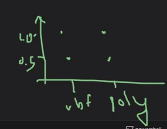

# Setup

We start with [Give me some credit](https://www.kaggle.com/c/GiveMeSomeCredit) data that we used in the previous session.

In [1]:
%load_ext dotenv
%dotenv 
import os
import sys
sys.path.append(os.getenv('SRC_DIR'))
import pandas as pd
import numpy as np
import os
ft_path = os.getenv("CREDIT_DATA")
df_raw = pd.read_csv(ft_path)


In [2]:
df = df_raw.drop(columns = ["Unnamed: 0"]).rename(
    columns = {
        'SeriousDlqin2yrs': 'delinquency',
        'RevolvingUtilizationOfUnsecuredLines': 'revolving_unsecured_line_utilization', 
        'age': 'age',
        'NumberOfTime30-59DaysPastDueNotWorse': 'num_30_59_days_late', 
        'DebtRatio': 'debt_ratio', 
        'MonthlyIncome': 'monthly_income',
        'NumberOfOpenCreditLinesAndLoans': 'num_open_credit_loans', 
        'NumberOfTimes90DaysLate':  'num_90_days_late',
        'NumberRealEstateLoansOrLines': 'num_real_estate_loans', 
        'NumberOfTime60-89DaysPastDueNotWorse': 'num_60_89_days_late',
        'NumberOfDependents': 'num_dependents'
    }
).assign(
    high_debt_ratio = lambda x: (x['debt_ratio'] > 1)*1,
    missing_monthly_income = lambda x: x['monthly_income'].isna()*1,
    missing_num_dependents = lambda x: x['num_dependents'].isna()*1, 
)

Use a simple pipeline composed of:

+ Preprocessing steps.
+ Logistic Regression classifier.

We will explore the hyperparameter sapce by evaluating different regularization strategies and parameters.

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV # this is important
from sklearn.linear_model import LogisticRegression # classifier model

In [4]:
# numeric variables we want to engineer, scale a certain way
num_cols = ['revolving_unsecured_line_utilization', 'age',
       'num_30_59_days_late', 'debt_ratio', 'monthly_income',
       'num_open_credit_loans', 'num_90_days_late', 'num_real_estate_loans',
       'num_60_89_days_late', 'num_dependents', 
       # Although expressed as numbers, these columns are boolean:
       # 'high_debt_ratio',
       # 'missing_monthly_income', 
       # 'missing_num_dependents' 
       ]

pipe_num_simple = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
    ('standardizer', StandardScaler())
])

ctransform_simple= ColumnTransformer([
    ('numeric_simple', pipe_num_simple, num_cols),
], remainder='passthrough')

pipe_lr = Pipeline([
    ('preprocess', ctransform_simple),
    ('clf', LogisticRegression())
])
pipe_lr

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numeric_simple',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardizer',
                                                                   StandardScaler())]),
                                                  ['revolving_unsecured_line_utilization',
                                                   'age', 'num_30_59_days_late',
                                                   'debt_ratio',
                                                   'monthly_income',
                                                   'num_open_credit_loans',
                                                   'num_90_days_late',
                                                   'num_real_estate_loans',
                                                   'num_60_89_days_late',
                                                   'num_dependents'])])),
                ('clf', LogisticRegression())])

Obtain the parameters of the pipeline with `.get_params()`.

In [5]:
pipe_lr.get_params()
# this displays the entirety of the parameters
# there are a number of different parameters we can use

# steps are concatenated with a double _
# can go deep into pipeline to find deep steps
# the double __ is key to finding steps in pre-processing for pipelines and column transformers

{'memory': None,
 'steps': [('preprocess',
   ColumnTransformer(remainder='passthrough',
                     transformers=[('numeric_simple',
                                    Pipeline(steps=[('imputer',
                                                     SimpleImputer(strategy='median')),
                                                    ('standardizer',
                                                     StandardScaler())]),
                                    ['revolving_unsecured_line_utilization', 'age',
                                     'num_30_59_days_late', 'debt_ratio',
                                     'monthly_income', 'num_open_credit_loans',
                                     'num_90_days_late', 'num_real_estate_loans',
                                     'num_60_89_days_late', 'num_dependents'])])),
  ('clf', LogisticRegression())],
 'verbose': False,
 'preprocess': ColumnTransformer(remainder='passthrough',
                   transformers=[('numeric_simpl

## Setup the Splitting Strategy

In [6]:
X = df.drop(columns = 'delinquency') # this is our predictor column
Y = df['delinquency']

scoring = ['neg_log_loss', 'roc_auc', 'f1', 'accuracy', 'precision', 'recall']
# same scores as we used before

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)
# same splitting strategies that we are using


To perform the Grid Search we need to define a parameter grid:

- A parameter grid defines all of the combinations of parameters that we need to explore.
- The function `GridSearchCV()` performs an exhaustive search of parameter combinations.
- The parameter grid is defined as a dictionary of lists:

    * Each entry's key is the name of the parameter.
    * Each entry's value is the list of values that we would like to explore.

In [7]:
param_grid = {
    'clf__C': [0.01, 0.5, 1.0], # lassifier we want to modify
    'clf__penalty': ['l1', 'l2'], # penalties
    'clf__solver': ['liblinear'], # solvers
    }
# this is defined by parameter we want to modify 
# these args all come from the documentation 
# define dictionary and key-value pair
# list of values are numerical and numbers we use
# if strings we express as strings
# penalty parameter determines regularization strategy to use

# solve - one option - why use
# send configuration into a single file
# store somewhere and modify figureation somewhere
# not the code itself

# basically all models have solvers to find our ouputs

Some key inputs to [`GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) are:

+ `estimator`: the pipeline or classifier that we are tuning.
+ `param_grid`: the parameter grid defined as a dictionary of lists described above.
+ `n_jobs`: settings for parallel computation.
+ `refit`: options for refitting the model using the best-performing configuration.

In [8]:
grid_cv = GridSearchCV(
    estimator=pipe_lr, 
    param_grid=param_grid, 
    scoring = scoring, 
    cv = 5,
    refit = "neg_log_loss") # refit parameter, saying when performance scores are found, retrain to optimize those scoring values
grid_cv.fit(X_train, Y_train)

c:\Users\Alexander\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\compose\_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('numeric_simple',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('standardizer',
                                                                                          StandardScaler())]),
                                                                         ['revolving_unsecured_line_utilization',
                                                                          'age',
                                                                          'num_30_59_days_late',
                                                                          'debt_ratio',
                                                                          'monthly_income',
                                                                          'num_open_credit_loans',
                                                                          'num_90_days_late',
                                                                          'num_real_estate_loans',
                                                                          'num_60_89_days_late',
                                                                          'num_dependents'])])),
                                       ('clf', LogisticRegression())]),
             param_grid={'clf__C': [0.01, 0.5, 1.0],
                         'clf__penalty': ['l1', 'l2'],
                         'clf__solver': ['liblinear']},
             refit='neg_log_loss',
             scoring=['neg_log_loss', 'roc_auc', 'f1', 'accuracy', 'precision',
                      'recall'])

In [ ]:
# will get a training pipeline fitted using the machinery we described
# run through the 6 configurations with 5 fold cv

Access the cross-validation results using the property `.cv_results_`:

In [9]:
res = grid_cv.cv_results_
res = pd.DataFrame(res) # convert to df
res.columns

res[['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_clf__C', 'param_clf__penalty', 'param_clf__solver', 'params',
       'mean_test_neg_log_loss',
       'std_test_neg_log_loss', 'rank_test_neg_log_loss']].sort_values('rank_test_neg_log_loss')

# columns are informative
# mean fit time - getting aggregates for create learning curves
# get the scoring time
# the value of the parameter
# dictionary with all values and strings combined
# all of the different scores and splt 0 through to split 4
# use a to_csv() call to craete a full table of data to read through
# negative log loss for best ranking parameter

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_clf__C,param_clf__penalty,param_clf__solver,params,mean_test_neg_log_loss,std_test_neg_log_loss,rank_test_neg_log_loss
4,9.040804,0.365199,0.153395,0.022046,1.00,l1,liblinear,"{'clf__C': 1.0, 'clf__penalty': 'l1', 'clf__so...",-0.225373,0.000492,1
5,0.937882,0.043733,0.148978,0.012711,1.00,l2,liblinear,"{'clf__C': 1.0, 'clf__penalty': 'l2', 'clf__so...",-0.225374,0.000488,2
2,9.764754,0.707773,0.160882,0.010553,0.50,l1,liblinear,"{'clf__C': 0.5, 'clf__penalty': 'l1', 'clf__so...",-0.225374,0.000488,3
3,1.020388,0.045562,0.160434,0.014582,0.50,l2,liblinear,"{'clf__C': 0.5, 'clf__penalty': 'l2', 'clf__so...",-0.225377,0.000481,4
0,6.664042,0.875653,0.169510,0.028677,0.01,l1,liblinear,"{'clf__C': 0.01, 'clf__penalty': 'l1', 'clf__s...",-0.227513,0.000446,5
1,0.907243,0.040632,0.159566,0.013444,0.01,l2,liblinear,"{'clf__C': 0.01, 'clf__penalty': 'l2', 'clf__s...",-0.228725,0.000628,6


Access the best-performing configuration:

In [10]:
grid_cv.best_params_
# dictionary of the best parameters

{'clf__C': 1.0, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}

In [11]:
grid_cv.best_estimator_
# best estimator is the refitted model using the entire training set

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numeric_simple',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardizer',
                                                                   StandardScaler())]),
                                                  ['revolving_unsecured_line_utilization',
                                                   'age', 'num_30_59_days_late',
                                                   'debt_ratio',
                                                   'monthly_income',
                                                   'num_open_credit_loans',
                                                   'num_90_days_late',
                                                   'num_real_estate_loans',
                                                   'num_60_89_days_late',
                                                   'num_dependents'])])),
                ('clf', LogisticRegression(penalty='l1', solver='liblinear'))])

In [ ]:
# can push this out to a pickle file
# specific file that is serialized
# save to pickle file can be opened in python programmed, objects exist in the program when opened


The best-performing classifier (pipeline) trained on the complete training set is:

# Tracking GridSearchCV Experiments

+ We can expand our infrastructure for hyperparameter tuning across various models.
+ The plan:

    - Create a model ingredient to obtain the classifier object.
    - Create experiment param grids in json files to organize our parameter grids.
    - Schedule the experiments.


In [ ]:
# we are trying to build a factor of methods
# code to load data, then code to perform pre-processing steps
# write another piece of code that return a model of component together with parameter grid
# run experiment for the optimal solution and the best performance
# retrain the training data and store it  using a pickle file

# database ingrediant for additional information
# two components to track for experiment


## The Design

<div>
<img src=./images/05_experiment_setup.png width="75%">
</div>

Explore the code in `./05_src/credit_experiment.py` and `./05_src/credit_model_ingredient.py`:

+ `credit_model_ingredient.py` implements a function that returns a model given a string. This way, we can parametrize models in the experiment.
+ `credit_experiment.py` is modularized version of our previous file, `credit_experiment_nb.py` which only worked with Naive Bayes classifier.
+ The experiment is now further *modularized*: there are ingredients for most components and it can be broken down even more depending on the evolution of the model.

## Running Experiments from the Command Line

Access the experiment through the [Command Line Interface](https://sacred.readthedocs.io/en/stable/command_line.html).

```
cd src  # if required
python credit_experiment.py
```

We can also change the parameters of the experiment. For instance, using the same code, we can run an experiment with a logistic regression classifier using a basic (not power) preprocessing pipeline:

```
python .\credit_experiment.py with 'preprocessing="basic"' 'model="LogisticRegression"'
```

# A Few Notes About Sacred

+ Sacred is a powerful tool, but it is only the beginning.  
+ Sacred is useful in keeping track of experiments within a limited scope: it is not a project management tool.
+ It works well in SQL environments, but handling hyperparameters can be painful.
+ The natural backend is MongoDB, however not all workplaces have running instances.


In [ ]:
# scared establishes a database schema
# sacred creates it for us
# can give it additional information

# need to set up database server

## Experiment Schema

The database schema implemented by sacred is shown below. The schema is a useful representation of the code and setup of an experiment. The package offers a [metrics API](https://sacred.readthedocs.io/en/stable/collected_information.html#metrics-api), but we have decided to extend the framework with a few ad-hoc tables with performance metrics. 

The database backend is a database like any other: you can query it with Python, R, or PowerBI.

+ Server is located in localhost port 5432.
+ User and password are in the .env file in `./05_src/db/`.

<div>
<img src=./images/05_sacred_sql_schema.png width="40%">
</div>